<a href="https://colab.research.google.com/github/seokssaem/bigdata-2026/blob/main/AICE_%EB%AA%A8%EC%9D%98%EA%B3%A0%EC%82%AC15%ED%9A%8C_%EB%AC%B8%EC%A0%9C%EC%A7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AICE Associate 기출동형 문제 1회: 펭귄 체중 예측

**과제: 펭귄 신체 특성 기반 체중 예측**

**도메인: 생태/자연과학**

**배경:**  
남극 연구소 'AICE Lab'의 생태학자들은 펭귄의 종, 서식지, 부리 길이, 날개 길이 등 신체 특성 데이터를 수집해왔습니다. 직접 포획해 체중을 재는 작업은 시간이 오래 걸리고 동물에게 스트레스를 줍니다. 관측하기 쉬운 신체 특성 데이터만으로 체중을 예측하는 AI 모델을 개발하여 현장 조사의 효율성을 높이고자 합니다.

**데이터셋 설명 (파일명: `penguin.csv`)**

* `species`: 펭귄 종 (Adelie, Chinstrap, Gentoo)
* `island`: 서식 섬 (Biscoe, Dream, Torgersen)
* `bill_length_mm`: 부리 길이 (mm)
* `bill_depth_mm`: 부리 깊이 (mm)
* `flipper_length_mm`: 날개 길이 (mm)
* `sex`: 성별 (Male, Female)
* **`body_mass_g`**: 예측 목표(Target), 체중 (g)

**[유의사항]**
* 각 문항의 답안은 반드시 `# 여기에 답안코드를 작성하고 실행하세요` 또는 `# 여기에 답안을 입력하세요` 셀에 입력하세요.
* 코드 빈칸 문제는 `<#번호>` 표시된 부분을 채워 실행하세요.
* 빈칸에 들어갈 내용은 각 답안 셀(cell)에 별도로 입력하세요.
* 모든 답안은 주피터 노트북 환경이라고 가정하며, 지시사항에 맞게 알맞은 라이브러리를 활용해 코드를 작성해야 합니다.

**문제 유형: 회귀(Regression) | 총 문제 수: 14문제**

---
#### 다음 문제를 풀기 전에 아래 코드를 실행하세요.

In [113]:
# 1. 한글 폰트 지원 라이브러리 설치
!pip install koreanize-matplotlib -q

# 2. 라이브러리 불러오기
import warnings
import koreanize_matplotlib

# 3. 경고 메시지 숨기기
warnings.filterwarnings('ignore')

---
#### 문제 01

펭귄 체중 예측을 위한 데이터 분석과 회귀 모델링에 필요한 라이브러리를 불러오세요.

조건은 다음과 같습니다.
- pandas는 pd로 불러오세요.
- numpy는 np로 불러오세요.
- matplotlib.pyplot은 plt로 불러오세요.
- seaborn은 sns로 불러오세요.
- LinearRegression과 RandomForestRegressor를 불러오세요.

In [114]:
# 답안
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression # 선형회귀
from sklearn.ensemble import RandomForestRegressor # 랜덤포레스트 회귀

---
#### 문제 02

penguin.csv 파일을 불러와 penguin_df 변수에 저장하고, 데이터의 기본 구조를 확인하세요.

조건은 다음과 같습니다.

- pd.read_csv()를 사용하세요.
- 데이터프레임 변수명은 penguin_df로 지정하세요.
- 데이터의 크기를 출력하세요.
- 앞 5개 행을 출력하세요.

In [115]:
# 답안
penguin_df = pd.read_csv('penguin.csv')
penguin_df.shape  # (행 개수, 열 개수)
penguin_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex,body_mass_g
0,Adelie,Dream,38.6,19.3,186,Male,5759
1,Gentoo,Dream,47.8,13.7,215,Female,7269
2,Gentoo,Biscoe,46.9,14.6,211,Female,7282
3,Chinstrap,Torgersen,50.1,17.8,199,Female,5820
4,Adelie,Dream,38.7,19.1,203,Female,5659


---
#### 문제 03
모델링 전에 데이터 타입과 결측치 현황을 확인하려 합니다.

3-1. 데이터 프레임의 기본 정보를 출력하세요.

In [116]:
# 답안
penguin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            500 non-null    object 
 1   island             500 non-null    object 
 2   bill_length_mm     500 non-null    float64
 3   bill_depth_mm      500 non-null    float64
 4   flipper_length_mm  500 non-null    int64  
 5   sex                475 non-null    object 
 6   body_mass_g        500 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 27.5+ KB


3-2. isnull()과 sum()을 이용해 컬럼별 결측치 개수를 확인하세요.

In [117]:
# 답안
penguin_df.isnull().sum()


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
sex,25
body_mass_g,0


3-3. 결측치가 존재하는 컬럼은 무엇인가요?

In [118]:
# 답안
penguin_df.columns[penguin_df.isnull().sum() > 0]

Index(['sex'], dtype='object')

---
#### 문제 04
시각화와 통계값을 함께 사용하여 펭귄의 종별 평균 체중을 비교하려 합니다.

4-1. species별 body_mass_g 평균을 막대그래프로 시각화하세요.

조건은 다음과 같습니다.
- sns.barplot()을 사용하세요.
- x축은 species, y축은 body_mass_g로 설정하세요.
- 그래프 제목은 'Species별 평균 체중'으로 설정하세요.

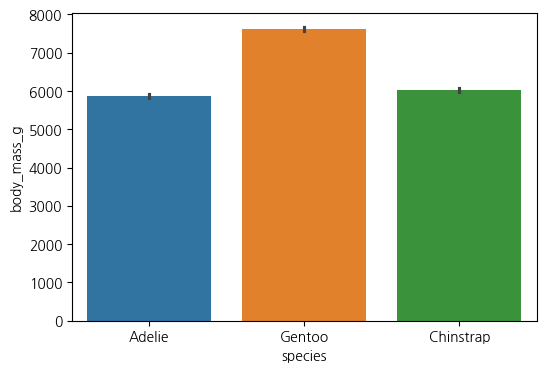

In [119]:
# 답안
plt.figure(figsize=(6, 4))
sns.barplot(data=penguin_df, x='species', y='body_mass_g', hue='species')
plt.show()

4-2. species별 평균 체중을 계산하세요.

In [120]:
# 답안
penguin_df.groupby('species')['body_mass_g'].mean()

,body_mass_g
species,
Adelie,5869.352657
Chinstrap,6026.172662
Gentoo,7606.344156


4-3. 평균 체중이 가장 높은 종은 무엇인가요?

In [121]:
# 답안
species_mean = penguin_df.groupby('species')['body_mass_g'].mean()
species_mean.idxmax()

'Gentoo'

---
#### 문제 05
flipper_length_mm와 body_mass_g 사이의 관계를 확인하려 합니다.

5-1. 두 변수의 관계를 jointplot으로 시각화하세요.
- x축: flipper_length_mm, y축: body_mass_g
- kind='reg' 옵션을 사용하여 회귀선을 함께 표시하세요.

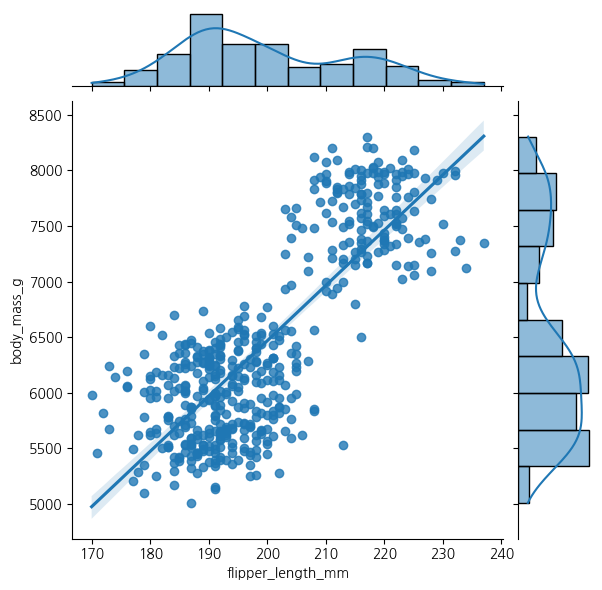

In [122]:
# 답안
sns.jointplot(data=penguin_df, x='flipper_length_mm', y='body_mass_g' ,
              kind='reg')
plt.show()


5-2. flipper_length_mm와 body_mass_g의 상관계수를 계산하세요.

In [123]:
#답안
penguin_df['flipper_length_mm'].corr(penguin_df['body_mass_g'])

np.float64(0.8046086170527548)

---
#### 문제 06
sex 컬럼의 결측치를 최빈값으로 처리하세요.

조건은 다음과 같습니다.

- sex 컬럼의 최빈값을 확인하세요.
- sex 컬럼의 결측치를 최빈값으로 대체하세요.
- 결측치 처리 후 전체 결측치 개수를 출력하세요.
- 다음 코드를 사용하세요

In [124]:
print('처리 전 결측치:', penguin_df['sex'].isnull().sum())

# 여기에 답안을 작성하세요.
sex_mode = penguin_df['sex'].mode()[0]

print('최빈값:', sex_mode)

# 여기에 답안을 작성하세요.
penguin_df['sex'] = penguin_df['sex'].fillna(sex_mode)

print('처리 후 전체 결측치 수:', penguin_df.isnull().sum().sum())

처리 전 결측치: 25
최빈값: Male
처리 후 전체 결측치 수: 0


---
#### 문제 07
species, island, sex 컬럼을 원-핫 인코딩하세요.

조건은 다음과 같습니다.
- pd.get_dummies()를 사용하세요.
- 결과는 penguin_encoded 변수에 저장하세요.
- 다중공선성 방지를 위해 drop_first=True를 설정하세요.
- 인코딩 후 데이터의 컬럼 수를 출력하세요.
- 인코딩 후 데이터프레임의 상위 5개만 출력하세요.

In [125]:
# 답안
penguin_encoded = pd.get_dummies(data=penguin_df, columns=['species', 'island', 'sex'],
                          drop_first=True)
penguin_encoded.shape


(500, 9)

In [126]:
penguin_encoded.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_Male
0,38.6,19.3,186,5759,False,False,True,False,True
1,47.8,13.7,215,7269,False,True,True,False,False
2,46.9,14.6,211,7282,False,True,False,False,False
3,50.1,17.8,199,5820,True,False,False,True,False
4,38.7,19.1,203,5659,False,False,True,False,False


---
#### 문제 08
body_mass_g를 예측하기 위해 피처 데이터와 타깃 데이터를 분리한 뒤, 훈련 데이터와 검증 데이터로 나누세요.
- 대상 데이터프레임: penguin_encoded

8-1. scikit-learn의 train_test_split를 import 하세요.

In [127]:
# 답안
from sklearn.model_selection import train_test_split

8-2. X와 y의 값을 저장하세요. body_mass_g를 y로(df.drop 사용), 나머지 컬럼을 X로 할당하세요.

In [128]:
# 답안
X = penguin_encoded.drop('body_mass_g', axis=1)
y = penguin_encoded['body_mass_g']

8-3. 훈련 데이터와 검증 데이터를 분리하세요.
- 검증 데이터 비율은 20%로 설정하세요.
- random_state=42
- 훈련 데이터와 검증 데이터의 크기를 출력하세요.

In [129]:
# 답안
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'학습 세트: {X_train.shape}, 검증 세트: {X_valid.shape}')

학습 세트: (400, 8), 검증 세트: (100, 8)


---
#### 문제 09
수치형·인코딩된 피처들의 스케일을 표준화하려 합니다.

9-1. StandardScaler를 생성하세요.

In [130]:
# 답안
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

9-2. 훈련 데이터에는 fit_transform(), 검증 데이터에는 transform()을 적용하세요.

In [131]:
# 답안
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

9-3. 스케일링된 검증 데이터의 전체 최댓값을 반올림하여 출력하세요.

In [132]:
# 답안
print(round(np.max(X_valid_scaled)))

3


---
#### 문제 10
펭귄 체중을 예측하기 위해 두 개의 회귀 모델을 학습하세요.

10-1. LinearRegression 모델을 학습하세요.
조건은 다음과 같습니다.
- 모델은 model_lr 변수에 저장하세요.
- 학습 데이터는 X_train_scaled, y_train을 사용하세요.

In [133]:
# 여기에 답안을 작성하세요.
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

print('LinearRegression 학습 완료')

LinearRegression 학습 완료


10-2. RandomForestRegressor 모델을 학습하세요.
조건은 다음과 같습니다.

- 모델은 model_rf 변수에 저장하세요.
- max_depth=5를 설정하세요.
- random_state=42를 설정하세요.
- 학습 데이터는 X_train_scaled, y_train을 사용하세요.

In [134]:
# 여기에 답안을 작성하세요.
model_rf = RandomForestRegressor(max_depth=5, random_state=42)
model_rf.fit(X_train_scaled, y_train)

print('RandomForestRegressor 학습 완료')

RandomForestRegressor 학습 완료


---
#### 문제 11
모델의 해석력을 이해하기 위해 RandomForest 모델의 특성 중요도를 파악하려 합니다.

11-1. 다음 가이드에 따라 특성 중요도를 파악하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요.

1.  특성 중요도 점수와 변수 이름을 매핑하여 DataFrame 을 만드세요.
2.  중요도 점수를 기준으로 내림차순 정렬하고 상위 5개만 선정하세요.
3. 중요도 점수를 수평 막대 그래프( barplot )로 시각화하세요.



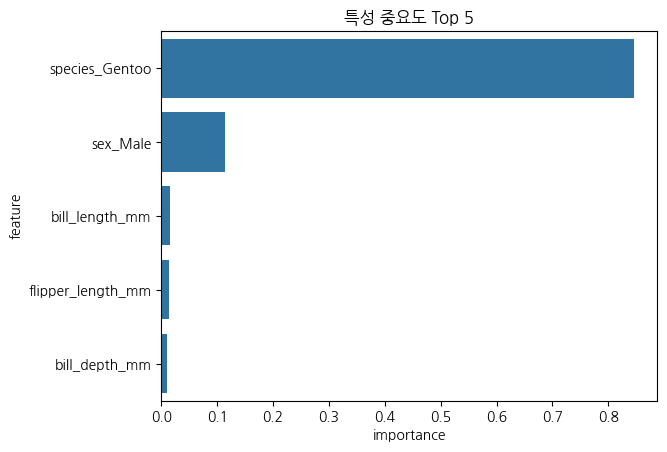

In [135]:
#(코드 셀) 다음 코드의 오류를 정정하고 실행하세요.

fi = pd.DataFrame({
    'feature': X.columns,
    'importance': model_rf.feature_importances_
})

# 중요도가 높은 순서로 정렬 후 상위 5개
fi = fi.sort_values('importance', ascending=False)[:5]

# 그래프
sns.barplot(x='importance', y='feature', data=fi)

plt.title('특성 중요도 Top 5')
plt.show()

11-2. 출력된 그래프에서 가장 높은 중요도를 보이는 변수명을 작성하세요.

---
#### 문제 12
앞서 학습한 LinearRegression과 RandomForestRegressor 모델의 성능을 비교하세요.

12-1. 두 모델의 MAE와 R² Score를 계산하세요.
조건은 다음과 같습니다.

- mean_absolute_error와 r2_score를 사용하세요.
- 검증 데이터 X_valid_scaled, y_valid를 사용하세요.
- 각 모델의 MAE와 R² Score를 출력하세요.

In [136]:
from sklearn.metrics import mean_absolute_error, r2_score

# 선형회귀 예측값
lr_pred = model_lr.predict(X_valid_scaled)

# 선형회귀 MAE
lr_mae = mean_absolute_error(y_valid, lr_pred)

# 선형회귀 R²
lr_r2 = r2_score(y_valid, lr_pred)


# 랜덤포레스트 회귀 예측값
rf_pred = model_rf.predict(X_valid_scaled)

# 랜덤포레스트 MAE
rf_mae = mean_absolute_error(y_valid, rf_pred)

# 랜덤포레스트 R²
rf_r2 = r2_score(y_valid, rf_pred)


print(f'LinearRegression MAE: {lr_mae:.2f}')
print(f'LinearRegression R² : {lr_r2:.4f}')

print(f'RandomForest MAE: {rf_mae:.2f}')
print(f'RandomForest R² : {rf_r2:.4f}')

LinearRegression MAE: 205.14
LinearRegression R² : 0.9082
RandomForest MAE: 205.59
RandomForest R² : 0.9092


12-2. 회귀 평가 지표 중 값이 1에 가까울수록 좋은 지표를 고르세요.
1. MAE
2. R² Score
3. Loss
4. Error

In [137]:
# 답안
2


2

---
#### 문제13
TensorFlow Keras를 사용하여 펭귄 체중을 예측하는 딥러닝 회귀 모델을 구성하세요.

13-1. Sequential 모델을 사용하세요.

조건은 다음과 같습니다.
- 첫 번째 은닉층은 Dense(64, activation='relu')로 구성하세요.
- 두 번째 은닉층은 Dense(32, activation='relu')로 구성하세요.
- 출력층은 Dense(1, activation='linear')로 구성하세요.
- 입력 특성 수는 X_train_scaled.shape[1]을 사용하세요.

In [138]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 여기에 답안을 작성하세요.
model = Sequential([
    Dense(64, activation='relu',
              input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

13-2. EarlyStopping을 사용하세요.
- monitor='val_loss', patience=10, restore_best_weights=True로 설정하세요.
- estop 변수에 저장하세요.

In [139]:
from tensorflow.keras.callbacks import EarlyStopping

# 여기에 답안을 작성하세요.
estop = EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True)

13-3. 모델 컴파일 단계에서 최적화 방법, 손실 함수, 평가 지표를 설정하세요.
- 최적화 알고리즘은 Adam, 손실 함수는 mse, 평가지표는 mae를 사용하세요.

In [140]:
# 답안
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

13-4. 컴파일된 모델을 실제 데이터로 학습시키세요.
- 학습에 사용될 입력 데이터와정답은 X_train_scaled, y_train 입니다.
- 전체 학습 데이터를 최대 100번 반복 학습합니다.
- 한 번에 32개씩 데이터를 묶어서 가중치를 업데이트 합니다.
- 과적합 모니터링 용으로 매 epoch마다 검증 데이터로 성능을 평가합니다.
- EarlyStopping 콜백을 적용합니다.
- 학습 진행 상황을 출력하지 않습니다.
- 학습 결과는 history 변수에 저장하세요.

In [141]:
# 여기에 답안을 작성하세요.
history = model.fit(X_train_scaled, y_train,
                            epochs=100,
                            batch_size=32,
                            validation_data=(X_valid_scaled, y_valid),
                            callbacks=[estop],
                            verbose=0)

print('딥러닝 모델 학습 완료')

딥러닝 모델 학습 완료


---
#### 문제 14
앞서 학습한 딥러닝 모델의 학습 과정을 확인하려 합니다.

14-1. 학습 Loss와 검증 Loss를 하나의 그래프로 시각화하세요.
- title은 'Model Loss'라고 합니다.
- xlabel은 'Epoch', ylable은 'Loss'로 설정하세요.

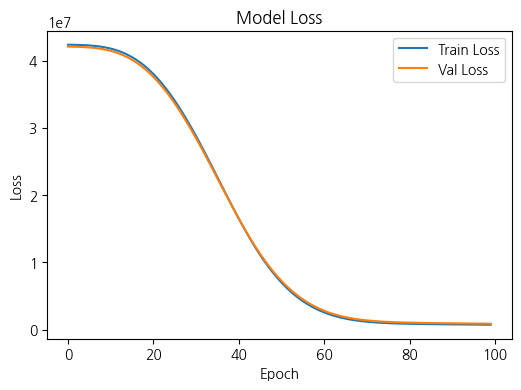

In [142]:
# 답안
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend() # 범례
plt.show()

14-2. 가장 낮은 검증 Loss와 해당 epoch를 출력하세요.

In [143]:
# 여기에 답안을 작성하세요.

best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss) + 1

print('최저 검증 Loss:', round(best_val_loss, 4))
print('최저 검증 Loss epoch:', best_epoch)

최저 검증 Loss: 871538.375
최저 검증 Loss epoch: 100


14-3. 딥러닝 모델의 검증 MAE를 평가하세요.

In [144]:
# 여기에 답안을 작성하세요.
dl_loss, dl_mae = model.evaluate(X_valid_scaled, y_valid)
print('검증 Loss:', round(dl_loss, 4))
print('검증 MAE:', round(dl_mae, 4))

model.evaluate(X_valid_scaled, y_valid)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 871538.3750 - mae: 747.6093 
검증 Loss: 871538.375
검증 MAE: 747.6093
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 871538.3750 - mae: 747.6093 


[871538.375, 747.6093139648438]

# 일반적인 현업 Github README.md 구조

## 1. 프로젝트 한 줄 소개 + 버전 배치
- 제목 아래에 한 두 문장으로 무엇을 하는
프로젝트인지 설명하고, 필요하면 Python/라이브러리 버전 배치를 붙힌다

## 2. 배경 및 문제 정의
- 왜 이 문제를 푸는지, 회귀/분류 등 문제 유형과 타겟 변수를 짧게 정리

## 3. 데이터 설명
- 데이터 출처, 행/열 수, 주요 컬럼과 의미를 표로 정리한다.
- 결측치 처리 방침도 있담녀 추가한다.

## 4. 파이프라인/아키텍처
- EDA -> 전처리 -> 모델링 -> 평가 로 이어지는 흐름을 번호 목록이나 다이어그램으로 보여준다.

## 5. 주요 결과 (표)
- 모델별 MAE, MSE, RMSE, r2 score, 정확도, 정밀도, 재현율, f1-score 등 지료를 표로 정리해서 한눈에 비교되게 한다.
- 가능하면 그래프 이미지도 추가한다.

## 6. 인사이트 & 한계
- 결과에서 도출한 비즈니스/도메인 인사이트와 데이터 크기나 인과관계 해석의 한계를 명확히 구분해서 쓴다.

## 7. 실행 방법(How to Run)
- git clone, 가상환경 설정, 의존성 설치, 실행 커맨드 까지 그대로 복사 붙여넣기 해서 돌아가게 코드 블록으로 제공

## 8. 폴더 구조
- 저장소 트리 구조를 코드 블록으로 보여줘서 어디에 무엇이 있는지 바로 파악되게 한다.

### 그 외
- 딥러닝 결과처럼 실행마다 값이 달라지는 항목은 "실행 환경에 따라 변동" 또는 재현 시드(`random_state`, `tf.random.set_seed`)를 명시해서 재현성을  확보한다.
- 그래프 이미지는  `results/` 폴더에 저장해서 README에 `![](results/파일명.png)` 형태로 삽입하는 경우가 많다.

# 프로젝트 보고서

관측이 쉬운 펭귄의 신체 득성(부리 길이, 날개 길이 등) 만으로 체중(body_mass_g)을  예측하는 회귀 프로젝트 입니다.
직접 포획해서 체중을 재는 대신 모델 예측값으로 대체해 현장조사기간과 개체 스트레스를 줄이는 것을 목표롷나다.

`python 3.12`
`scikit-learn`
`TensorFlow/keras`
`pandas`
`seaborn`
`matplotlib`

---

## 배경 및 문제 정의

- **도메인** : 생태/자연과학 (남극 펭귄 개체 조사)
- **문제 유형** : 회귀(Regression) - 타겟이 연속값(g단위 체중)이기 때문
- **타겟 변수** : `body_mass_g`
- **입력 변수** : 종(`species`), 서식 섬(`island`), 부리 길이/깊이, 날개 길이, 성별

## 데이터

| 항목 | 내용 |
|---|---|
| 크기 | 500행 X 7열 |
| 결측치 | `sex` 컬럼 25개(최빈값 `Male`로 대체) |
| 범주형 처리 | `species`, `island`, `sex` -> One-Hot Encoding(`drop_first=True`) |
| 인코딩 후 컬럼 수 | 9개 |
| Train / valid | 400 / 100 (`test_size=0.2`, `random_state42`) |

**주요 컬럼**
| 컬럼 | 설명 |
| --- | --- |
| `species` | 펭귄 종(Adelie, Chinstrap, Gentoo) |
| `island` | 서식 섬 (Biscoe, Dream, Torgersen) |
| `bill_length_mm` | 부리 길이 |
| `bill_depth_mm` | 부리 깊이 |
| `flipper_lengrh_mm` | 날개 길이 (mm) |
| `sex`| 성별 |
| `body_mass_g` | **예측 대상**, 체중 (g) |

## 파이프라인

```
1. EDA : 종별 평균 체중 비교, 날개 길이-체중 상관관계 확인
2. 전처리 : 결측치(최빈값) -> One-Hot Encoding -> Train/Valid 분리 -> Standardscaler
3. 모델링 : LinearRegression / RandomForestRegressor / keras DNN
4. 평가 : MAE, R2 score 비교 +  특성 중요도 분석
```
## 주요 결과

| 모델 | MAE | R2 score |
| --- | --- | --- |
| LinearRegression | 205.14 | 0.9082 |
| RandomForestRegressor (`max_depth=5`) | 205.59 | 0.902 |
| Keras DNN (64->32->1, EarlyStopping) | 실행 환경에 따라 변동 | 실행 환경에 따라 변동 |

- 날개 길이 와 체중의 상관계수는 **0.8**으로 강한 양의 상관관계를 보임
- RandomForestRegressor 특성 중요도 1위는 `species_Gentoo` (중요도 0.85) 종이 다른 종보다 확연히 체구가 크다는 EDA 결과와 일치

## 인사이트 & 한계

- **인사이트** : 종(species) 정보 하나만으로도 체중 변동의 상당 부분이 설명됨.
- 신체 치수 계측 없이 종, 섬 정보만 확보해도 1차 스크리닝용 체중 추정이 가능할 수 있음

- **한계** : 특성 중요도가 높다고 해서 인과관계를 의미하지는 않음
(`species_Gentoo`가 크다는 것은 상관관계이지 원인 규명이 아님)
- 표본 500개,  3개 종에 한정된 데이터라 다른 서식지, 계절 데이터에는 일반화가 제한적임

## 항후 개선 방향

- 계절 / 개체 나이 변수 추가
- 딥러닝 모델 하이퍼파라미터 튜닝, 교차 검증으로 성능 재검증



